<a href="https://colab.research.google.com/github/Kommmi/Quantum-Dynamical-Systems/blob/main/01_GQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Global state and environment-conditioned decomposition

The global state of a multibody system can be written as when focusing on a subsystem $S_a$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{L_S}\sum_{j=1}^{L_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$

We consider a three-qubit state with one subsystem qubit $S$ and two environment qubits $E$
$$
|\Psi_{SE}\rangle =
\frac{1}{\sqrt{8}}
\left(|000\rangle+|001\rangle+|010\rangle+|011\rangle
+|100\rangle+|101\rangle+|110\rangle-|111\rangle\right).
$$

Taking the first qubit as system $S_0$ and the last two as environment $E$. The environment basis is $\{|e_j⟩\}_{j=1}^{4} = \{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}.$ The environment conditioned decomposition is:
$$
|\Psi_{SE}\rangle
=
\frac{1}{\sqrt{8}}((|0\rangle+|1\rangle)|00\rangle
+(|0\rangle+|1\rangle)|01\rangle
+(|0\rangle+|1\rangle)|10\rangle
+(|0\rangle-|1\rangle)|11\rangle) ,
$$

Further simplified as:

$$
|\Psi_{SE}\rangle
=
\frac{1}{2}|\chi_1^{S_0}\rangle|00\rangle
+\frac{1}{2}|\chi_1^{S_0}\rangle|01\rangle
+\frac{1}{2}|\chi_1^{S_0}\rangle|10\rangle
+\frac{1}{2}|\chi_2^{S_0}\rangle|11\rangle ,
$$

where

$$
|\chi_1^{S_0}\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\qquad
|\chi_1^{S_0}\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

Thus each environment outcome has probability

$$
\lambda_j^E=\frac{1}{4}.
$$

### 2. Local state: density matrix

The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho_{S_0} =
\sum_{j=1}^{4}\lambda_j^E
|\chi_j^{S_0}\rangle\langle \chi_j^{S_0}|.
$$

For this example,

$$
\rho_{S_0}
=
\frac{3}{4}|\chi_1^{S_0}\rangle\langle \chi_1^{S_0}|
+\frac{1}{4}|\chi_2^{S_0}\rangle\langle \chi_2^{S_0}|.
$$

In the computational basis,

$$
\rho_{S_0} =
\begin{pmatrix}
1/2 & 1/4 \\
1/4 & 1/2
\end{pmatrix}.
$$

This is a mixed local state, even though the full three-qubit state is pure.

### 3. Local state: geometric quantum state

The same local state can be represented as a probability measure over pure subsystem states:

$$
Q^{S_0} =
\sum_{j=1}^{4}
\lambda_j^E
\delta_{|\chi_j^{S_0}\rangle}.
$$

Since three environment outcomes give $|\chi_1^{S_0}\rangle$ and one gives $|\chi_2^{S_0}\rangle $,

$$
Q^{S_0} =
\frac{3}{4}\delta_{|\chi_1^{S_0}\rangle}
+\frac{1}{4}\delta_{|\chi_2^{S_0}\rangle}.
$$

Thus the geometric quantum state keeps track of the pure states appearing in the environment-conditioned ensemble, together with their probabilities.

In [1]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Quantum-Dynamical-Systems.git

# Move into the repo
%cd Quantum-Dynamical-Systems

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site, random_wavefunction, print_density_matrix, print_gqs_single_site, print_wavefunction
from gqs.plotsCompare import plot_gqs_and_density_matrix

In [3]:
from gqs import*
from gqs.distances import Psi_Dist, _mask_chi_lambda

Global State
(-0.1529-0.0651j) |000>      + (0.2265-0.0865j) |001>       + (0.4081-0.1428j) |010>       + (0.0527+0.2379j) |011>       +
(0.4570-0.3048j) |100>       + (0.2026+0.3447j) |101>       + (-0.1864-0.0559j) |110>      + (0.2811-0.2980j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.3327       -0.1581-0.0399j  
|1>        -0.1581+0.0399j        0.6673      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(-0.266-0.113j) |0> + (0.796-0.531j) |1>,0.329000
1,1,|01>,(0.484-0.185j) |0> + (0.433+0.737j) |1>,0.219000
2,2,|10>,(0.861-0.301j) |0> + (-0.393-0.118j) |1>,0.225000
3,3,|11>,(0.111+0.499j) |0> + (0.590-0.625j) |1>,0.227000


Reduced States Plot


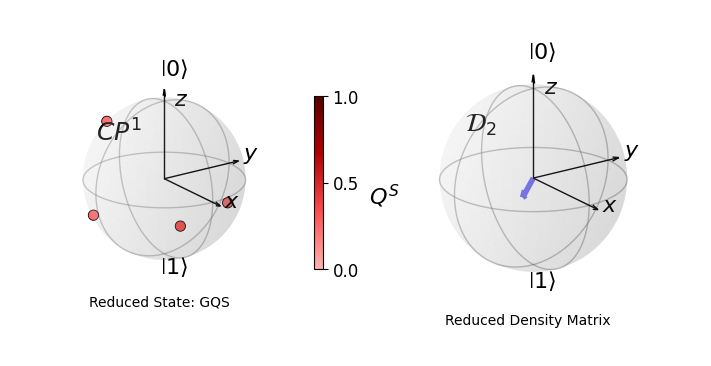

In [11]:
dhilbert = 2
nchain = 3
system_site = 0
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.1082-0.0379j) |000>       + (0.4293-0.2873j) |001>       + (0.3835+0.2758j) |010>       + (-0.1072-0.3287j) |011>      +
(0.2451+0.1743j) |100>       + (-0.0572+0.2390j) |101>      + (-0.3209+0.2415j) |110>      + (0.0460+0.2512j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.4308        0.1003+0.0378j  
|1>         0.1003-0.0378j        0.5692      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 1
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.223-0.078j) |0> + (0.789+0.567j) |1>,0.236000
1,1,|01>,(0.691-0.462j) |0> + (-0.172-0.529j) |1>,0.386000
2,2,|10>,(0.489+0.347j) |0> + (-0.640+0.481j) |1>,0.252000
3,3,|11>,(-0.161+0.674j) |0> + (0.130+0.709j) |1>,0.126000


Reduced States Plot


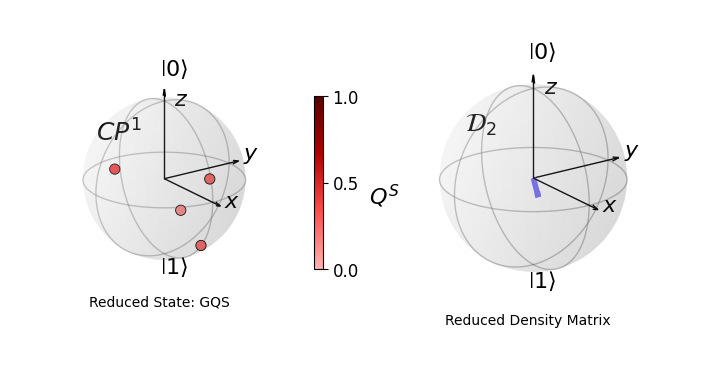

In [ ]:
system_site = 1
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.0133+0.2086j) |000>       + (-0.2068-0.3783j) |001>      + (-0.0418+0.1237j) |010>      + (0.0738+0.2121j) |011>       +
(-0.2489+0.2877j) |100>      + (0.1995-0.6084j) |101>       + (0.1080-0.1657j) |110>       + (0.2965+0.1458j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.2446       -0.2753-0.1790j  
|1>        -0.2753+0.1790j        0.7554      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 2
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.028+0.435j) |0> + (-0.432-0.790j) |1>,0.230000
1,1,|01>,(-0.161+0.476j) |0> + (0.284+0.817j) |1>,0.067000
2,2,|10>,(-0.334+0.386j) |0> + (0.268-0.817j) |1>,0.555000
3,3,|11>,(0.281-0.430j) |0> + (0.770+0.379j) |1>,0.148000


Reduced States Plot


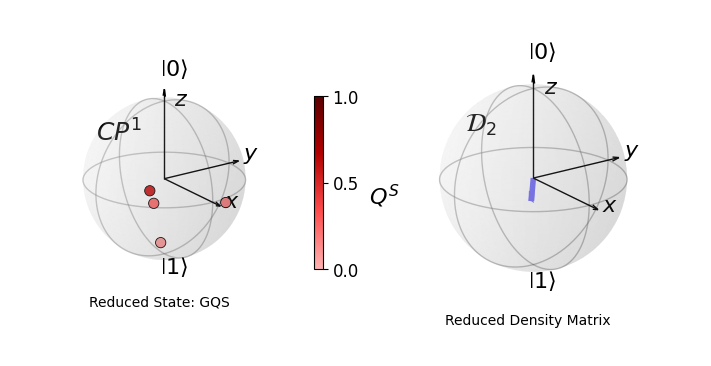

In [ ]:
system_site = 2
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.0071-0.1993j) |0000>      + (0.3042+0.0951j) |0001>      + (0.1303-0.0992j) |0010>      + (-0.0570-0.0834j) |0011>     +
(-0.0738-0.0632j) |0100>     + (-0.2323+0.0771j) |0101>     + (0.0084-0.2267j) |0110>      + (0.2057-0.2706j) |0111>      +
(0.0481+0.4125j) |1000>      + (-0.0507-0.1185j) |1001>     + (-0.0682-0.0197j) |1010>     + (0.2937+0.1942j) |1011>      +
(-0.2715-0.1789j) |1100>     + (0.1242-0.0241j) |1101>      + (-0.3103-0.0624j) |1110>     + (-0.2123+0.0126j) |1111>    

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.4147       -0.1833+0.1483j  
|1>        -0.1833-0.1483j        0.5853      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 8



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.015-0.433j) |0> + (0.104+0.895j) |1>,0.212000
1,1,|01>,(0.885+0.277j) |0> + (-0.147-0.345j) |1>,0.118000
2,2,|10>,(0.730-0.556j) |0> + (-0.382-0.111j) |1>,0.032000
3,3,|11>,(-0.156-0.228j) |0> + (0.802+0.530j) |1>,0.134000
4,4,|100>,(-0.218-0.186j) |0> + (-0.800-0.527j) |1>,0.115000
5,5,|101>,(-0.843+0.280j) |0> + (0.451-0.087j) |1>,0.076000
6,6,|110>,(0.021-0.582j) |0> + (-0.797-0.160j) |1>,0.152000
7,7,|111>,(0.513-0.675j) |0> + (-0.529+0.032j) |1>,0.161000


Reduced States Plot


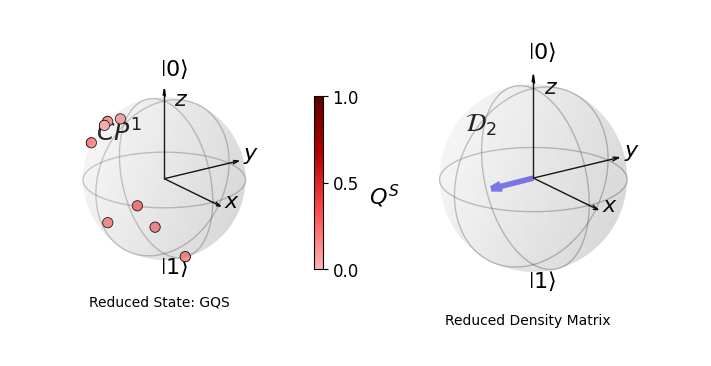

In [ ]:
dhilbert = 2
nchain = 4
system_site = 0
psi = random_wavefunction(4)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)

Global State
(-0.2875+0.1024j) |00000>    + (0.1832-0.1643j) |00001>     + (-0.0462-0.1015j) |00010>    + (-0.1728-0.1670j) |00011>    +
(0.2143+0.0530j) |00100>     + (-0.1752+0.0789j) |00101>    + (-0.0013+0.1073j) |00110>    + (-0.0459+0.0479j) |00111>    +
(-0.0477+0.0568j) |01000>    + (0.0922+0.1294j) |01001>     + (-0.0190+0.3066j) |01010>    + (-0.2098+0.0222j) |01011>    +
(-0.0058-0.0219j) |01100>    + (-0.0978+0.2045j) |01101>    + (0.1182-0.1021j) |01110>     + (-0.0093+0.1212j) |01111>    +
(-0.1248-0.0969j) |10000>    + (-0.2453-0.2353j) |10001>    + (-0.1040-0.0666j) |10010>    + (0.1147+0.1457j) |10011>     +
(-0.0513-0.1364j) |10100>    + (-0.0841+0.0733j) |10101>    + (0.0350-0.0323j) |10110>     + (-0.0725+0.1478j) |10111>    +
(0.0230-0.0034j) |11000>     + (0.1157+0.0947j) |11001>     + (0.2204+0.0075j) |11010>     + (0.0794+0.0446j) |11011>     +
(-0.1345+0.0164j) |11100>    + (0.1634-0.1479j) |11101>     + (0.0953-0.0029j) |11110>     + (0.0155-0.0682j) |11111>  

,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(-0.837+0.298j) |0> + (-0.363-0.282j) |1>,0.118000
1,1,|01>,(0.437-0.391j) |0> + (-0.585-0.561j) |1>,0.176000
2,2,|10>,(-0.278-0.610j) |0> + (-0.625-0.400j) |1>,0.028000
3,3,|11>,(-0.569-0.550j) |0> + (0.378+0.480j) |1>,0.092000
4,4,|100>,(0.810+0.201j) |0> + (-0.194-0.516j) |1>,0.070000
5,5,|101>,(-0.789+0.355j) |0> + (-0.379+0.330j) |1>,0.049000
6,6,|110>,(-0.011+0.914j) |0> + (0.298-0.275j) |1>,0.014000
7,7,|111>,(-0.259+0.270j) |0> + (-0.409+0.833j) |1>,0.032000
8,8,|1000>,(-0.614+0.731j) |0> + (0.296-0.044j) |1>,0.006000
9,9,|1001>,(0.422+0.593j) |0> + (0.530+0.434j) |1>,0.048000


Reduced States Plot


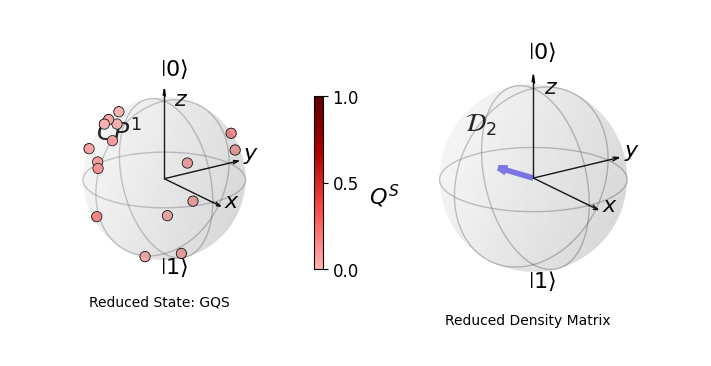

In [ ]:
dhilbert = 2
nchain = 5
system_site = 0
psi = random_wavefunction(5)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)